# Logistic regression for Heart disease risk Prediction

In this notebook, we construct a baseline probabilistic model for estimating heart disease risk using logistic regression.

Modeling choices are motivated by exploratory data analysis (EDA), with emphasis on interpretability and statistical validity rather than maximizing predictive performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve, auc,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("data/heart_disease_uci.csv", index_col='id')

In [3]:
cl = df[df["dataset"] == "Cleveland"].copy()
cl.shape

(304, 15)

Based on exploratory analysis, we restrict modeling to the Cleveland subset.

In [4]:
cl.isnull().sum()

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       1
ca          5
thal        3
num         0
dtype: int64

In [5]:
cl = cl.dropna()
cl.shape

(297, 15)

The Cleveland subset contains minimal missing values.
Given the low frequency of missingness, rows with missing entries are excluded rathan than imputed to aviod introducing additional assumptions.

In [6]:
num_vars = ["age", "trestbps", "chol", "thalch", "oldpeak"]
cat_vars = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

In [7]:
cl["target"] = (cl["num"] >= 1).astype(int)
cl["target"].value_counts(normalize=True)

target
0    0.538721
1    0.461279
Name: proportion, dtype: float64

The original outcome variable represents disease severity.
For risk screening purposes, we model disease presence as a binary outcome, where 0 represents false and 1 represents true.

In [8]:
features = num_vars + cat_vars

X = cl[features]
y = cl["target"]

In [9]:
#Drop the first category to avoid multicollinearity(dummy variable trap)
X = pd.get_dummies(X, columns = cat_vars, drop_first=True)
X.shape

(297, 17)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

Stratified splitting ensures that disease prevalence is preserved between training and test sets because proportions are close in the Cleveland dataset.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Standardization is applied to ensure that numerical predictors are on comparable scales, which stabilizes coefficient estimation.

In [12]:
logit = LogisticRegression(
    solver = "liblinear",
    penalty = "l2",
    random_state=42
)

logit.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


Logistic regression is selected as the baseline model in this case due to its probabilistic interpretation and transparency.

In [13]:
y_pred = logit.predict(X_test_scaled)
y_prob = logit.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8
ROC AUC: 0.9040178571428572


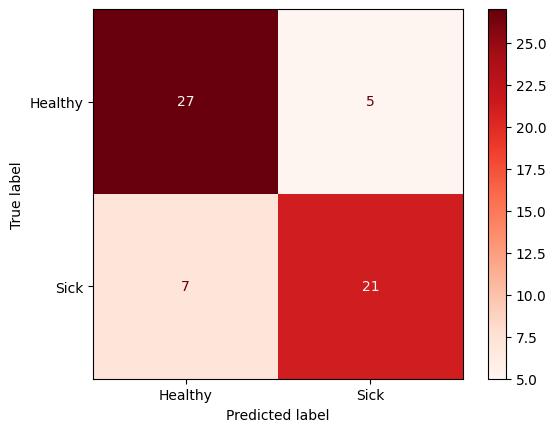

In [14]:
cm = confusion_matrix(y_test, y_pred)

cm_display_obj = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Sick'])

cm_display_obj.plot(cmap=plt.cm.Reds)
plt.show()

In a clinical screening context, false nagatives may carry a higher cost than flase positives, highlighting the need for careful threshold selection.


In [15]:

coef_cl = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logit.coef_[0]
})

coef_cl["Odds_Ratio"] = np.exp(coef_cl["Coefficient"])
coef_cl.sort_values(by="Odds_Ratio", ascending=False)


,Feature,Coefficient,Odds_Ratio
16,thal_reversable defect,0.657831,1.930600
4,oldpeak,0.573849,1.775086
5,sex_Male,0.546955,1.727983
1,trestbps,0.288446,1.334352
0,age,0.260517,1.297601
2,chol,0.224795,1.252066
12,exang_True,0.192513,1.212292
13,slope_flat,0.191582,1.211164
9,fbs_True,0.020959,1.021180
11,restecg_st-t abnormality,-0.028976,0.971440


Regression coefficients and odds ratios provide insight into which clinical factors are associated with increased risk, while controlling for other variables.

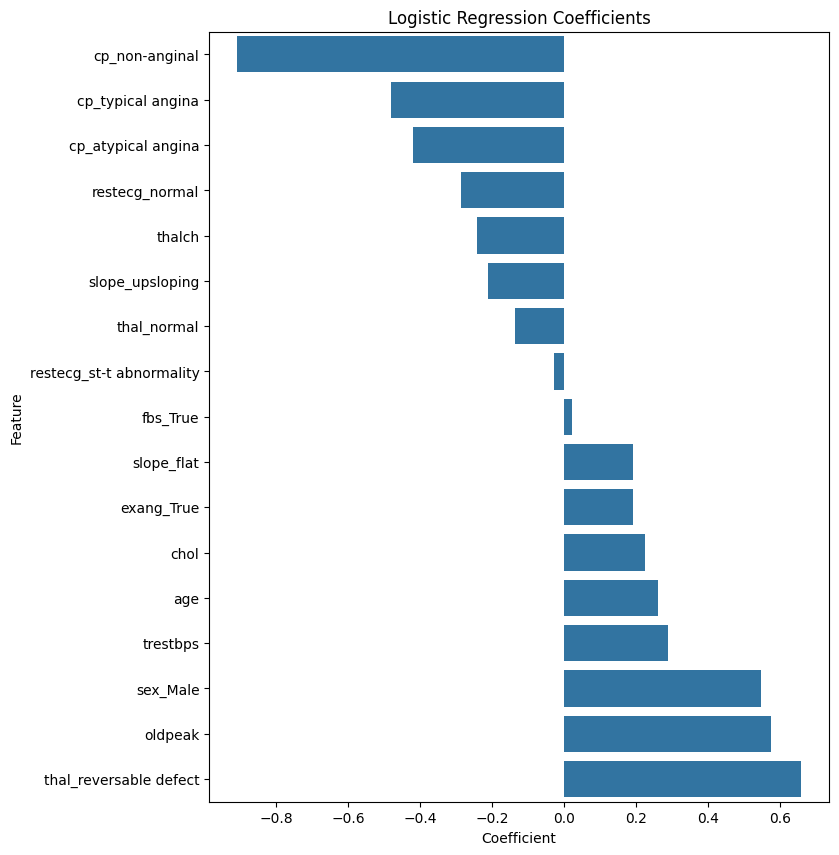

In [16]:

plt.figure(figsize=(8, 10))
sns.barplot(
    data=coef_cl.sort_values(by="Coefficient"),
    x="Coefficient",
    y="Feature"
)
plt.title("Logistic Regression Coefficients")
plt.show()


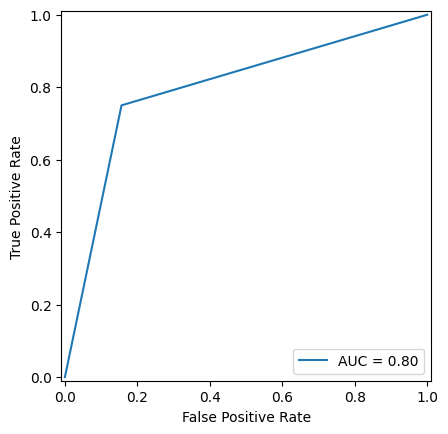

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc(fpr, tpr)).plot()
plt.show()

### Model Interpretation Summary

This logistic regression model provides an interpretable baseline for heart disease srik estimation by using the Cleveland subset of UCI Heart disease data.

Although the model is unable to capture complex nonlinear relationships, its transparency allows for clinical interpretation and serves as a foundation for uncertainty analysis in subsequent steps.